In [9]:
import pandas as pd
df = pd.read_csv('Mall_Customers.csv')

#2. Reading the Dataset   
#The first 5 rows (head()). 
print(df.head())

#Basic info (info()). 
df.info()

#Summary statistics (describe()). 
print(df.describe())

#To check whether any column contains NaN
df.isna().any()
#To see which columns and how many NaNs they have
df.isna().sum()
#To check if any NaNs exist in the entire DataFrame
df.isna().values.any()
# Impute numeric columns with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# Impute categorical columns with mode
for col in df.select_dtypes(include="object").columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# 3. Feature Selection 
#drop customerID column
df = df.drop(columns=["CustomerID"])

# Select features for clustering
features = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]
print(features.head())

# One-hot encode the Gender column
gender_encoded = pd.get_dummies(df["Gender"], drop_first=True)  # creates 0/1 columns

# Add encoded gender to the features
features = pd.concat([features, gender_encoded], axis=1)



   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
       CustomerID         Age  Annual Income (k$)  Spend

C:\Users\Naz\AppData\Local\Temp\ipykernel_21288\2321478891.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [ ]:
#4. Preprocessing 
#encode
import pandas as pd
df = pd.read_csv('Mall_Customers.csv')

# Assuming your features DataFrame already exists
# One-hot encode Gender
gender_encoded = pd.get_dummies(df["Gender"], prefix="Gender", drop_first=False)

# Add encoded Gender columns to features
features = pd.concat([features, gender_encoded], axis=1)
print(features.head())


   Age  Annual Income (k$)  Spending Score (1-100)   Male  Gender_Female  \
0   19                  15                      39   True          False   
1   21                  15                      81   True          False   
2   20                  16                       6  False           True   
3   23                  16                      77  False           True   
4   31                  17                      40  False           True   

   Gender_Male  Gender_Female  Gender_Male  Gender_Female  Gender_Male  
0         True          False         True          False         True  
1         True          False         True          False         True  
2        False           True        False           True        False  
3        False           True        False           True        False  
4        False           True        False           True        False  


In [25]:
#Scaling
import pandas as pd

df = pd.read_csv('Mall_Customers.csv')
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df = pd.read_csv('Mall_Customers.csv')
# Select only numeric columns (exclude any encoded categorical variables)
numeric_cols = features.select_dtypes(include=["int64", "float64"]).columns

features[numeric_cols] = scaler.fit_transform(features[numeric_cols])
print(features.head())
print(features[numeric_cols].mean())  # should be close to 0
print(features[numeric_cols].std())   # should be close to 1



        Age  Annual Income (k$)  Spending Score (1-100)   Male  Gender_Female  \
0 -1.424569           -1.738999               -0.434801   True          False   
1 -1.281035           -1.738999                1.195704   True          False   
2 -1.352802           -1.700830               -1.715913  False           True   
3 -1.137502           -1.700830                1.040418  False           True   
4 -0.563369           -1.662660               -0.395980  False           True   

   Gender_Male  Gender_Female  Gender_Male  Gender_Female  Gender_Male  
0         True          False         True          False         True  
1         True          False         True          False         True  
2        False           True        False           True        False  
3        False           True        False           True        False  
4        False           True        False           True        False  
Age                      -4.440892e-17
Annual Income (k$)        7.105427e-

In [26]:
#Final Feature Matrix
# Store the final preprocessed feature matrix
import pandas as pd
df = pd.read_csv('Mall_Customers.csv')
X_scaled = features.copy()

# Verify
print(X_scaled.head())
print(X_scaled.shape)


        Age  Annual Income (k$)  Spending Score (1-100)   Male  Gender_Female  \
0 -1.424569           -1.738999               -0.434801   True          False   
1 -1.281035           -1.738999                1.195704   True          False   
2 -1.352802           -1.700830               -1.715913  False           True   
3 -1.137502           -1.700830                1.040418  False           True   
4 -0.563369           -1.662660               -0.395980  False           True   

   Gender_Male  Gender_Female  Gender_Male  Gender_Female  Gender_Male  
0         True          False         True          False         True  
1         True          False         True          False         True  
2        False           True        False           True        False  
3        False           True        False           True        False  
4        False           True        False           True        False  
(200, 10)


In [27]:
#5.1 Dendrogram 
from scipy.cluster.hierarchy import linkage
import pandas as pd
df = pd.read_csv('Mall_Customers.csv')
# Use the Ward method for hierarchical clustering
Z = linkage(X_scaled, method='ward')
print(Z[:5])  # print first 5 rows of the linkage matrix


[[6.50000000e+01 6.80000000e+01 7.17666897e-02 2.00000000e+00]
 [1.29000000e+02 1.31000000e+02 7.17666897e-02 2.00000000e+00]
 [3.00000000e+00 5.00000000e+00 9.00803899e-02 2.00000000e+00]
 [1.14000000e+02 1.15000000e+02 1.05730374e-01 2.00000000e+00]
 [6.00000000e+01 7.00000000e+01 1.20910138e-01 2.00000000e+00]]


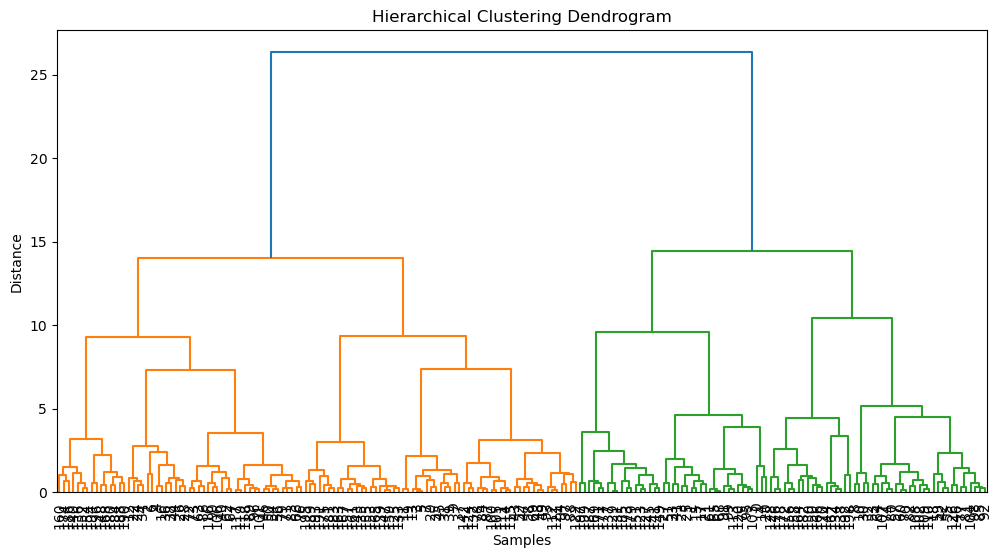

In [28]:
#Plot a dendrogram 
import pandas as pd
df = pd.read_csv('Mall_Customers.csv')
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
plt.figure(figsize=(12, 6))

# Plot full dendrogram
dendrogram(
    Z,  # linkage matrix from previous step
    leaf_rotation=90,  # rotate leaf labels for readability
    leaf_font_size=10
)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()


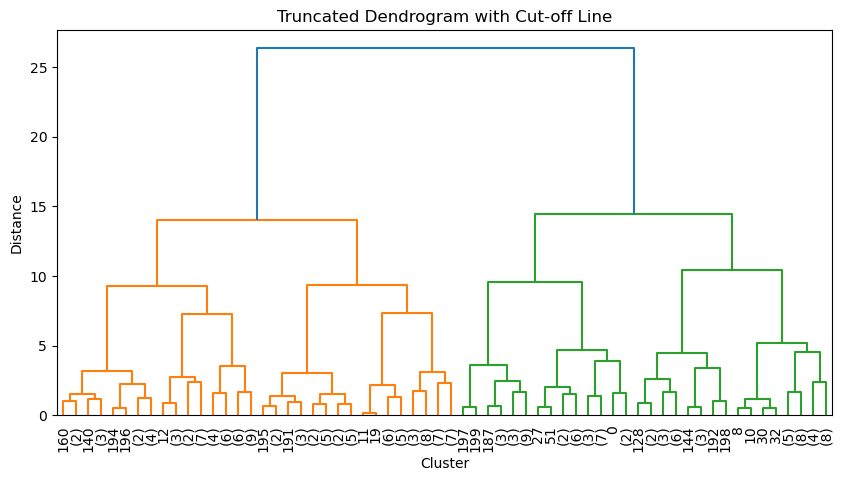

In [29]:
#Use AgglomerativeClustering 
from scipy.cluster.hierarchy import fcluster
import pandas as pd
df = pd.read_csv('Mall_Customers.csv')

plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode='level', p=5, leaf_rotation=90, leaf_font_size=10, show_contracted=True)
plt.axhline(y=150, color='r', linestyle='--')  # horizontal line at chosen threshold
plt.title('Truncated Dendrogram with Cut-off Line')
plt.xlabel('Cluster')
plt.ylabel('Distance')
plt.show()


Number of clusters: 2, Silhouette Score: 0.3700
Number of clusters: 3, Silhouette Score: 0.3451
Number of clusters: 4, Silhouette Score: 0.3183
Number of clusters: 5, Silhouette Score: 0.3320
Number of clusters: 6, Silhouette Score: 0.3507
Number of clusters: 7, Silhouette Score: 0.3598
Number of clusters: 8, Silhouette Score: 0.3919
Number of clusters: 9, Silhouette Score: 0.4064
Number of clusters: 10, Silhouette Score: 0.4346


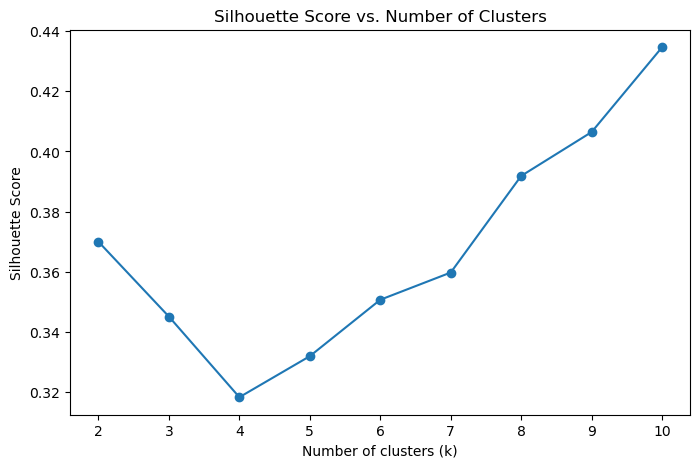

In [30]:
#For a range of cluster counts

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv('Mall_Customers.csv')

# Store silhouette scores for each k
silhouette_scores = {}

# Try cluster counts from 2 to 10
for k in range(2, 11):
    # Initialize AgglomerativeClustering (metric replaces affinity)
    clusterer = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    
    # Fit and predict cluster labels
    labels = clusterer.fit_predict(X_scaled)
    
    # Compute silhouette score
    score = silhouette_score(X_scaled, labels)
    
    silhouette_scores[k] = score
    print(f"Number of clusters: {k}, Silhouette Score: {score:.4f}")

# Plot silhouette scores
plt.figure(figsize=(8,5))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters')
plt.show()


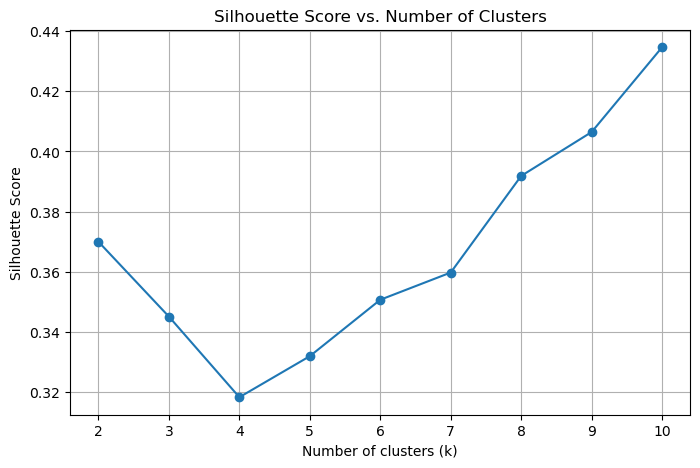

In [31]:
#Plot silhouette score vs number of clusters
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv('Mall_Customers.csv')

# Example: silhouette_scores is a dictionary {k: score}
# silhouette_scores = {2: 0.45, 3: 0.52, 4: 0.49, ...}

plt.figure(figsize=(8,5))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker='o', linestyle='-')
plt.xticks(range(2, 11))  # set x-axis ticks
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters')
plt.grid(True)
plt.show()


Best number of clusters: 10 with Silhouette Score: 0.4346


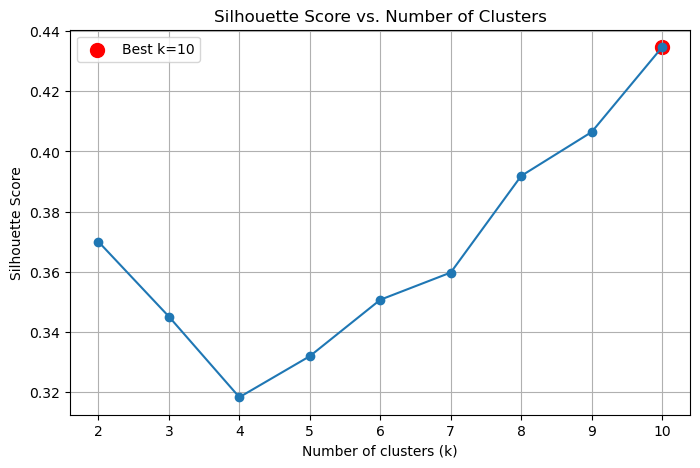

In [32]:
# Find the k with the maximum silhouette score
best_k = max(silhouette_scores, key=silhouette_scores.get)
best_score = silhouette_scores[best_k]

import pandas as pd
df = pd.read_csv('Mall_Customers.csv')

print(f"Best number of clusters: {best_k} with Silhouette Score: {best_score:.4f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker='o', linestyle='-')
plt.xticks(range(2, 11))
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters')

# Highlight the best k
plt.scatter(best_k, best_score, color='red', s=100, label=f'Best k={best_k}')
plt.legend()
plt.grid(True)
plt.show()



In [34]:
#5.3 Final Hierarchical Model 
#AgglomerativeClustering
import pandas as pd
df = pd.read_csv('Mall_Customers.csv')
from sklearn.cluster import AgglomerativeClustering

# Initialize the model with the best number of clusters
final_clusterer = AgglomerativeClustering(n_clusters=best_k, metric='euclidean', linkage='ward')

# Fit the model and predict cluster labels
final_labels = final_clusterer.fit_predict(X_scaled)

# Check the first few cluster labels
print(final_labels[:10])


[1 1 9 8 9 8 9 8 0 8]


In [ ]:
#cluster_agg.
import pandas as pd
df = pd.read_csv('Mall_Customers.csv')
# Add cluster labels to the original DataFrame
df['cluster_agg'] = final_labels

# Verify the result
print(df[['cluster_agg']].head())
print(df['cluster_agg'].value_counts())



   cluster_agg
0            1
1            1
2            9
3            8
4            9
cluster_agg
0    29
5    25
7    25
1    23
6    21
4    18
2    18
3    15
9    13
8    13
Name: count, dtype: int64


In [41]:
# Count customers per cluster
import pandas as pd
df = pd.read_csv('Mall_Customers.csv')

df['cluster_agg'] = final_labels

customer_counts = df['cluster_agg'].value_counts().sort_index()
print(customer_counts)





cluster_agg
0    29
1    23
2    18
3    15
4    18
5    25
6    21
7    25
8    13
9    13
Name: count, dtype: int64


In [ ]:
#Mean Age, Annual Income, Spending Score 
# Group by cluster and calculate mean values
from sklearn.cluster import AgglomerativeClustering

# Fit the final AgglomerativeClustering model with best_k clusters
final_clusterer = AgglomerativeClustering(n_clusters=best_k, metric='euclidean', linkage='ward')
final_labels = final_clusterer.fit_predict(X_scaled)

# Add cluster labels to your DataFrame
df['cluster_agg'] = final_labels
print(df.columns)



Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'cluster_agg'],
      dtype='object')


In [ ]:

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MeanShift
import numpy as np

df = pd.read_csv('Mall_Customers.csv')

# 2 Select features for clustering
features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Optional: encode Gender if needed
# features = pd.concat([features, pd.get_dummies(df['Gender'], prefix='Gender', drop_first=True)], axis=1)

# 3 Scale numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# 4 Initialize and fit MeanShift
ms = MeanShift()
ms.fit(X_scaled)

# 5 Predict cluster labels
mean_shift_labels = ms.labels_

# 6 Number of clusters found
n_clusters_ms = len(np.unique(mean_shift_labels))
print(f"Number of clusters found by MeanShift: {n_clusters_ms}")

# 7 Add cluster labels to the DataFrame
df['cluster_meanshift'] = mean_shift_labels

# 8 Verify
print(df[['cluster_meanshift']].head())




Number of clusters found by MeanShift: 1
   cluster_meanshift
0                  0
1                  0
2                  0
3                  0
4                  0


In [ ]:
#estimate_bandwidth()
import pandas as pd
df = pd.read_csv('Mall_Customers.csv')

from sklearn.cluster import MeanShift, estimate_bandwidth
# Estimate bandwidth automatically
bandwidth = estimate_bandwidth(X_scaled, quantile=0.2, n_samples=500)  # adjust quantile if needed
print(f"Estimated bandwidth: {bandwidth:.4f}")
# Initialize MeanShift with the estimated bandwidth
ms = MeanShift(bandwidth=bandwidth)

# Fit and predict cluster labels
ms.fit(X_scaled)
mean_shift_labels = ms.labels_

# Number of clusters found
n_clusters_ms = len(np.unique(mean_shift_labels))
print(f"Number of clusters found by MeanShift: {n_clusters_ms}")

# Add cluster labels to the DataFrame
df['cluster_meanshift'] = mean_shift_labels


Estimated bandwidth: 1.4980
Number of clusters found by MeanShift: 1


In [ ]:
#Fit a MeanShift model on X_scaled. 
from sklearn.cluster import MeanShift
import numpy as np

#  Initialize the MeanShift model
ms = MeanShift()  # optional: specify bandwidth=... if you want

#  Fit the model to the scaled features
ms.fit(X_scaled)

#  Predict cluster labels
mean_shift_labels = ms.labels_

#  Count number of clusters found
n_clusters_ms = len(np.unique(mean_shift_labels))
print(f"Number of clusters found by MeanShift: {n_clusters_ms}")

#  Optionally, add cluster labels to your original DataFrame
df['cluster_meanshift'] = mean_shift_labels

# 6 Verify
print(df[['cluster_meanshift']].head())


Number of clusters found by MeanShift: 1
   cluster_meanshift
0                  0
1                  0
2                  0
3                  0
4                  0


In [51]:
#Get the cluster labels and add them to the original DataFrame

from sklearn.cluster import MeanShift

# Fit MeanShift on X_scaled
ms = MeanShift()
ms.fit(X_scaled)

# Get the cluster labels
cluster_labels_ms = ms.labels_

# Add the labels to the original DataFrame
df['cluster_ms'] = cluster_labels_ms

# Verify
print(df[['cluster_ms']].head())
import numpy as np

n_clusters_ms = len(np.unique(cluster_labels_ms))
print(f"Number of clusters found by MeanShift: {n_clusters_ms}")


   cluster_ms
0           0
1           0
2           0
3           0
4           0
Number of clusters found by MeanShift: 1


In [ ]:
#6.2 MeanShift Cluster Analysis 